# 5장 3강: 배깅 vs 부스팅 선택과 모델 해석(SHAP)

## 실습 목표

이번 실습에서는 **Ames Housing** 데이터를 이용하여 배깅과 부스팅을 비교하고, SHAP으로 앙상블 모델의 예측 근거를 해석합니다.

- Random Forest와 XGBoost의 구조적 차이를 비교합니다.
- 성능과 학습 시간을 확인하여 상황에 맞는 모델 선택 기준을 정리합니다.
- Feature Importance의 특징과 한계를 확인합니다.
- TreeSHAP을 이용해 모델 전체의 **전역 해석**을 수행합니다.
- 특정 주택 한 건의 예측을 **지역 해석**합니다.
- SHAP 값의 부호를 이용하여 각 특성이 예측값을 올렸는지 내렸는지 설명합니다.

> 이 실습에서는 5장 3강 교안에 나온 배깅/부스팅 비교, Feature Importance, SHAP 전역·지역 해석 내용만 사용합니다.

## 실습 환경 / 데이터

- Python
- pandas
- matplotlib
- scikit-learn
- xgboost
- shap
- 데이터: `Ames_Housing.csv`

### 분석 목표

주택 특성을 이용하여 `SalePrice`를 예측하는 회귀 문제입니다.

### 사용할 특성

- `OverallQual`
- `GrLivArea`
- `GarageCars`
- `GarageArea`
- `TotalBsmtSF`
- `1stFlrSF`
- `2ndFlrSF`
- `FullBath`
- `TotRmsAbvGrd`
- `YearBuilt`
- `YearRemodAdd`
- `Fireplaces`

예측 대상은 `SalePrice`입니다.

## 실습 준비

1. Ames Housing 데이터를 불러옵니다.
2. 사용할 숫자형 특성과 `SalePrice`를 선택합니다.
3. Train / Test 데이터로 분리합니다.
4. Random Forest와 XGBoost를 같은 데이터에서 비교합니다.
5. SHAP은 XGBoost 모델을 대상으로 확인합니다.

In [3]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

house = pd.read_csv("Ames_Housing.csv")

features = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "GarageArea",
    "TotalBsmtSF",
    "1stFlrSF",
    "2ndFlrSF",
    "FullBath",
    "TotRmsAbvGrd",
    "YearBuilt",
    "YearRemodAdd",
    "Fireplaces"
]

X = house[features]
y = house["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train 크기:", X_train.shape)
print("Test 크기:", X_test.shape)

print("\n[결측치]")
display(X.isna().sum().to_frame("missing"))

Train 크기: (1168, 12)
Test 크기: (292, 12)

[결측치]


c:\Users\sjh96\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,missing
OverallQual,0
GrLivArea,0
GarageCars,0
GarageArea,0
TotalBsmtSF,0
1stFlrSF,0
2ndFlrSF,0
FullBath,0
TotRmsAbvGrd,0
YearBuilt,0


In [2]:
pip install shap

   ---------------------------------------- 0.0/43.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/43.0 MB 3.7 MB/s eta 0:00:12
   - -------------------------------------- 1.3/43.0 MB 3.6 MB/s eta 0:00:12
   - -------------------------------------- 2.1/43.0 MB 3.6 MB/s eta 0:00:12
   -- ------------------------------------- 2.9/43.0 MB 3.6 MB/s eta 0:00:12
   --- ------------------------------------ 3.4/43.0 MB 3.6 MB/s eta 0:00:12
   --- ------------------------------------ 3.7/43.0 MB 3.5 MB/s eta 0:00:12
   ---- ----------------------------------- 4.5/43.0 MB 3.1 MB/s eta 0:00:13
   ---- ----------------------------------- 5.2/43.0 MB 3.2 MB/s eta 0:00:12
   ----- ---------------------------------- 5.8/43.0 MB 3.2 MB/s eta 0:00:12
   ----- ---------------------------------- 6.0/43.0 MB 3.2 MB/s eta 0:00:12
   ------ --------------------------------- 6.8/43.0 MB 3.1 MB/s eta 0:00:12
   ------ --------------------------------- 7.3/43.0 MB 3.0 MB/s eta 0:00:12
   ---

---

# 필수 1. 배깅과 부스팅 비교 및 선택

## 문제 1. Random Forest와 XGBoost를 비교하세요.

### 요구사항

다음 두 모델을 사용합니다.

```python
RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
```

각 모델에 대해 다음을 확인합니다.

1. Train 데이터로 학습합니다.
2. 학습 시간을 측정합니다.
3. Test 데이터를 예측합니다.
4. Test RMSE를 계산합니다.
5. Test R²를 계산합니다.
6. 결과를 하나의 DataFrame으로 정리합니다.

### 확인 포인트

- Random Forest가 배깅 계열이라는 점을 이해했는가?
- XGBoost가 부스팅 계열이라는 점을 이해했는가?
- 성능뿐 아니라 학습 시간도 함께 확인했는가?

In [4]:
# TODO
# Random Forest와 XGBoost의 Test RMSE, Test R², 학습 시간을 비교하세요.

models = {
    "RandomForest (배깅)": RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ),
    "XGBoost (부스팅)": XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),
}

rows = []
for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    fit_time = time.time() - start

    pred = model.predict(X_test)

    rows.append({
        "model": name,
        "fit_time_sec": round(fit_time, 4),
        "test_rmse": round(mean_squared_error(y_test, pred) ** 0.5, 1),
        "test_r2": round(r2_score(y_test, pred), 4)
    })

model_result = pd.DataFrame(rows)
print(model_result.to_string(index=False))

rf, xgb = model_result.iloc[0], model_result.iloc[1]
print(f"\n학습 시간 : RF {rf['fit_time_sec']}초 / XGB {xgb['fit_time_sec']}초"
      f"  (XGB가 RF의 {xgb['fit_time_sec'] / rf['fit_time_sec']:.2f}배)")
print(f"Test RMSE : 차이 {abs(rf['test_rmse'] - xgb['test_rmse']):,.1f}")
print(f"Test R2   : 차이 {abs(rf['test_r2'] - xgb['test_r2']):.4f}")

            model  fit_time_sec  test_rmse  test_r2
RandomForest (배깅)        0.5420    29206.6   0.8888
    XGBoost (부스팅)        0.1752    28405.3   0.8948

학습 시간 : RF 0.542초 / XGB 0.1752초  (XGB가 RF의 0.32배)
Test RMSE : 차이 801.3
Test R2   : 차이 0.0060


### Q1. Random Forest와 XGBoost의 학습 방식은 어떻게 다른가요?

**답변:**  
Random Forest / Bagging  
-> 여러 나무를 독립적으로 학습하고 예측을 평균  

XGBoost / Boosting  
-> 나무를 순차적으로 쌓으면서 앞 모델이 남긴 오차를 다음 모델이 보완

### Q2. 다음 상황에서 어떤 방식을 우선 후보로 생각할 수 있는지 작성하세요.

1. 빠르게 베이스라인을 만들고 싶고 튜닝 여력이 적음  
여러 나무를 독립적으로 학습하고 예측을 평균하기 때문에  
-> Random Forest

2. 시간을 들여 예측 성능을 더 끌어올리고 싶음  
Boosting 계열 (XGBoost)

3. 노이즈가 많아 과적합 위험을 조심해야 함  
각 독립적으로 학습하기 때문에 노이즈를 덜 받아들이는 경향이 있음  
-> Random Forest를 우선 후보로 생각할 수 있음

---

# 필수 2. Feature Importance와 SHAP 전역 해석

## 문제 1. XGBoost의 Feature Importance를 확인하세요.

### 요구사항

1. 필수 1에서 학습한 XGBoost 모델을 사용합니다.
2. `feature_importances_`를 이용합니다.
3. 특성명과 중요도를 DataFrame으로 만듭니다.
4. 중요도가 높은 순서대로 정렬합니다.
5. 막대그래프로 표시합니다.

### 확인 포인트

- 어떤 특성이 모델 전체에서 중요하게 사용되었는지 확인했는가?
- 중요도의 크기는 알 수 있지만 방향은 알 수 없다는 점을 이해했는가?

[XGBoost Feature Importance]
     feature  importance  cumulative
 OverallQual      0.4660      0.4660
  GarageCars      0.1311      0.5971
   GrLivArea      0.0865      0.6836
    1stFlrSF      0.0612      0.7448
    FullBath      0.0465      0.7913
    2ndFlrSF      0.0425      0.8338
 TotalBsmtSF      0.0419      0.8757
  Fireplaces      0.0410      0.9167
YearRemodAdd      0.0343      0.9510
   YearBuilt      0.0270      0.9780
  GarageArea      0.0133      0.9913
TotRmsAbvGrd      0.0089      1.0002

중요도 합계 : 1.0000
상위 3개 합계 : 0.6836


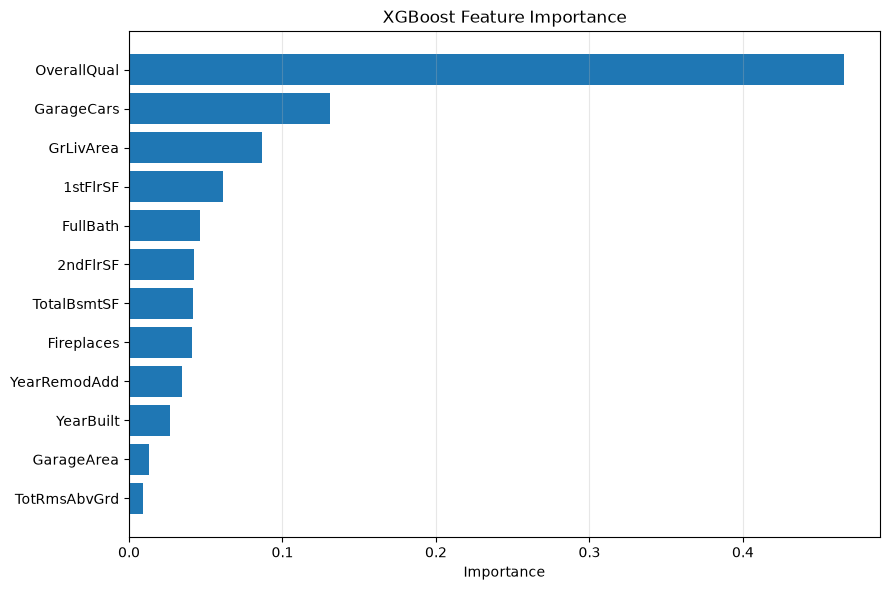

In [ ]:
# TODO
# XGBoost의 Feature Importance를 표와 그래프로 확인하세요.
xgb_model = models["XGBoost (부스팅)"]

importance_result = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

importance_result["importance"] = importance_result["importance"].round(4)
importance_result["cumulative"] = importance_result["importance"].cumsum().round(4)

print("[XGBoost Feature Importance]")
print(importance_result.to_string(index=False))
print(f"\n중요도 합계 : {xgb_model.feature_importances_.sum():.4f}")
print(f"상위 3개 합계 : {importance_result['importance'][:3].sum():.4f}")

plt.figure(figsize=(9, 6))
plt.barh(importance_result["feature"], importance_result["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("XGBoost Feature Importance")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

OverallQual이 약 0.46으로 현재 모델에서 중요도를 차지하고 있다.  
GarageCars가 약 0.13으로 현재 모델에서 두번째로 높은 중요도를 차지하고있다.  

### Q3. Feature Importance만으로는 알기 어려운 정보는 무엇인가요?

**답변:**  
예측을 높이는지 낮추는지에 대한 방향성(음/양)을 알 수 없다.  
특정 샘플 한 건에 대한 개별적인 기여도(중요도)에 근거를 알기 여렵다.  

## 문제 2. TreeSHAP으로 전역 중요도를 확인하세요.

### 요구사항

1. `shap.TreeExplainer()`에 XGBoost 모델을 전달합니다.
2. Test 데이터의 SHAP 값을 계산합니다.
3. `shap.plots.bar()`로 전역 중요도를 확인합니다.
4. SHAP 절댓값의 평균도 계산하여 특성별 중요도를 DataFrame으로 정리합니다.
5. 상위 특성을 확인합니다.

### 확인 포인트

- SHAP은 각 특성이 예측값에 기여한 정도를 계산한다는 점을 이해했는가?
- 전역 SHAP에서는 여러 샘플의 기여도 크기를 종합해 전체 중요도를 볼 수 있는가?

SHAP 값 배열 크기 : (292, 12)
기준값(base value): 181,446.4

[SHAP 전역 중요도 - 절댓값 평균]
     feature  mean_abs_shap
 OverallQual        26019.0
   GrLivArea        14752.9
 TotalBsmtSF         9006.5
YearRemodAdd         7363.1
  Fireplaces         5914.1
   YearBuilt         5241.9
  GarageCars         4220.3
    1stFlrSF         3454.6
  GarageArea         2379.3
    2ndFlrSF         2307.3
    FullBath         1972.8
TotRmsAbvGrd          263.2

상위 3개 합계 : 49,778.4
전체 합계     : 82,895.0


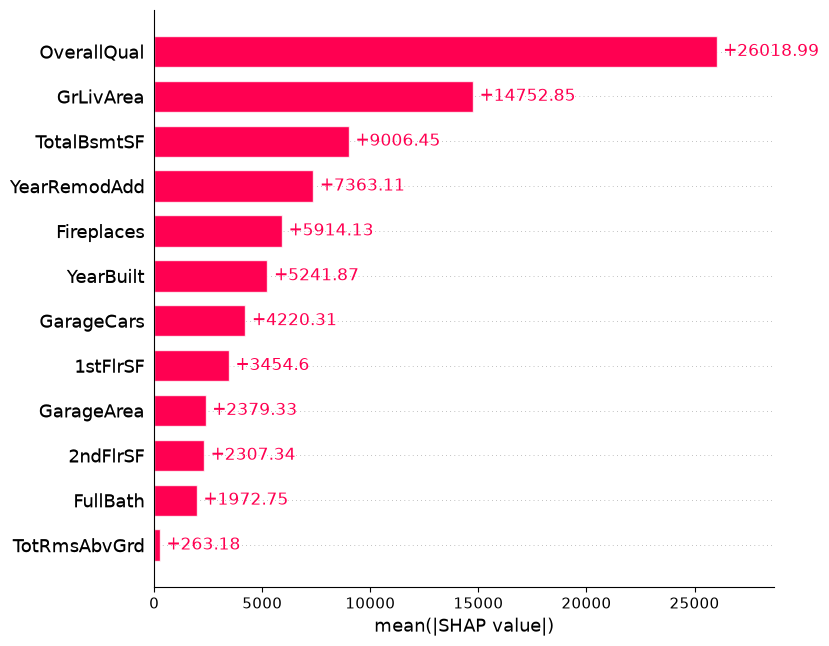

In [6]:
# TODO
# TreeSHAP을 이용해 XGBoost 모델의 전역 SHAP 중요도를 확인하세요.

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_test)

print("SHAP 값 배열 크기 :", shap_values.values.shape)
print("기준값(base value):", f"{shap_values.base_values[0]:,.1f}")

shap_result = pd.DataFrame({
    "feature": X_test.columns,
    "mean_abs_shap": np.abs(shap_values.values).mean(axis=0).astype(float).round(1)
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

print("\n[SHAP 전역 중요도 - 절댓값 평균]")
print(shap_result.to_string(index=False))
print(f"\n상위 3개 합계 : {shap_result['mean_abs_shap'][:3].sum():,.1f}")
print(f"전체 합계     : {shap_result['mean_abs_shap'].sum():,.1f}")

shap.plots.bar(shap_values, max_display=12)

[OverallQual 26,019의 의미]  
test 주택 각각에서 품질에 배분된 SHAP값의 절대값을 평균했더니 26,019 가격 단위였다.  

**막대가 빨간색이로 +표시가 있는 거 상승인가요?**  
아니다. |SHAP Value| 절대값이기 때문에 항상 예측이 양인 것을 의미하는 것은 아니다.  

기존 중요도와 순위가 다른 이유?  
기존 모델에서 Feature Importance에서는 GarageCar가 2위였는데 SHAP에서는 7위다.  
SHAP에서는 Test 주택 예측 차이에 배분한 기여 크기를 평균하기 떄문에  
앞서 Feature Importance와 계산 원리와 집계 대상이 다르기 때문에 기존 중요도와 순위가 다를 수 있다.  

### Q4. Feature Importance와 SHAP의 가장 큰 차이는 무엇인가요?

**답변:**  
Feature Importance는 주로 모델 전체에서 중요도의 크기를 보여준다면  
SHAP는 전역 중요도, 개별 예측을 설명할 때 각 특성의 양수/음수의 방향성을 보고싶을 때까지 확인이 가능하다.

---
# 과제 1. 모델 비교·SHAP 해석과 특성 선택 전후 검증

## 배경
주택 가격 예측 모델을 성능과 학습 시간으로 비교하고, SHAP으로 예측 근거를 설명합니다. 이어서 중요한 특성을 선택했을 때 검증 성능이 어떻게 달라지는지 확인합니다.

> 필수 1·2는 연습용입니다. 아래 과제의 비교표·해석·코드를 제출하세요. 준비 단계의 `X_train`, `y_train`을 사용하되 과제용 모델을 새로 학습합니다. Test 결과로 모델이나 특성을 선택하지 않도록, Train 안에서 Validation을 분리합니다. 개별 주택 해석 대상도 Validation의 첫 번째 주택으로 맞춥니다.

## 요구사항

### 1. 같은 조건에서 모델 비교
1. `X_train`, `y_train`을 Train_sub / Validation으로 나누세요(`test_size=0.2`, `random_state=42`). 결측값이 있으면 Train_sub에서 구한 중앙값으로 두 데이터를 채우세요.
2. Random Forest(`n_estimators=200`)와 XGBoost(`n_estimators=200`, `learning_rate=0.05`, `max_depth=3`)를 같은 Train_sub에서 학습하세요. 두 모델 모두 `random_state=42`, `n_jobs=1`로 설정하세요.
3. 각 모델의 **fit에 걸린 시간**, Train_sub RMSE, Validation RMSE와 R²를 `model_comparison`으로 정리하세요. 시간은 같은 환경에서 측정하며, 한 번의 측정만으로 일반적인 속도 우열을 단정하지 마세요.
4. 예측 오차, 학습 시간, Train/Validation 오차 차이와 운영 목적을 근거로 우선 후보를 선택하세요. 모델 선택 결과와 관계없이 다음 해석은 XGBoost로 수행합니다.

### 2. Feature Importance와 SHAP 전역·지역 해석
5. 과제용 XGBoost의 `feature_importances_`와 **Train_sub의 평균 절댓값 SHAP**을 각각 순위로 정리하여 `importance_comparison`으로 비교하세요. 전역 SHAP 막대그래프도 제출하세요.
6. Validation의 첫 번째 주택의 실제 가격·예측가격을 확인하고 SHAP waterfall plot을 그리세요.
7. 해당 주택의 절댓값 SHAP 상위 5개 특성·특성값·SHAP 값을 `local_top5`로 정리하세요. 양수·음수의 의미를 설명하고 기준값 + 모든 SHAP 값의 합이 예측값과 거의 같은지 확인하세요.
8. 두 전역 중요도 산출 원리와 한계를 비교하고, 전역 순위와 개별 주택의 기여도가 다른 이유를 설명하세요.

### 3. 중요도에 근거한 특성 선택 및 검증
9. Train_sub의 평균 절댓값 SHAP이 높은 **상위 6개 특성**을 선택하세요. 특성 선택은 이번 과제의 특성 개선 시도입니다. 개수는 비교 결과를 보기 전에 6개로 고정합니다.
10. 선택한 특성만 사용하여 동일한 XGBoost 설정으로 다시 학습하세요. 기존 모델과 동일한 Train_sub / Validation 행을 사용하고, 특성 이외의 조건은 유지하세요.
11. 전체 특성 모델과 선택 특성 모델의 특성 수·학습 시간·Train RMSE·Validation RMSE·Validation R²를 `feature_comparison`으로 비교하세요. `기존 Validation RMSE - 선택 후 Validation RMSE`와 기존 대비 개선율(%)을 계산하세요.
12. 개선 여부와 채택 여부를 수치로 설명하세요. 성능이 나빠져도 원인 가능성과 한계를 타당하게 설명하면 됩니다. 검증 결과를 반복 확인하며 특성을 바꾸지 말고, 최종 일반화 성능 확인에는 별도 Test 평가가 필요함을 밝히세요.

## 해석 질문

### Q5. 전역 SHAP에서 가장 중요한 특성이 특정 주택에서도 반드시 가장 큰 영향을 주나요?
### Q6. SHAP 값이 양수/음수라는 것은 각각 무엇을 의미하나요?
### Q7. 두 모델 중 무엇을 우선 후보로 선택했나요? 성능·학습 시간·과적합 징후와 주택 가격 예측 업무를 연결하여 설명하세요.
### Q8. Feature Importance와 평균 절댓값 SHAP의 계산 원리와 한계는 무엇이며, 실제 상위 특성 순위는 어떻게 다른가요?
### Q9. 상위 6개 특성은 무엇이며, 선택 전후 RMSE 차이와 개선율은 얼마인가요? 이 시도를 채택할지와 판단의 한계를 설명하세요.

## 제출물 / 확인 포인트
- `model_comparison`, `importance_comparison`, 전역 SHAP 그래프
- 개별 주택의 실제값·예측값·waterfall plot·`local_top5`·SHAP 합 검증
- 선택한 6개 특성, `feature_comparison`, RMSE 차이와 개선율
- 계산 코드와 Q5~Q9 답변
- 동일한 검증 조건 유지, SHAP의 방향·전역/지역 구분, 관측한 개선 여부와 해석의 한계

In [7]:
# TODO 1: 같은 Train_sub / Validation으로 두 모델의 성능과 fit 시간을 비교하세요.

X_sub, X_val, y_sub, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

median_values = X_sub.median()
X_sub = X_sub.fillna(median_values)
X_val = X_val.fillna(median_values)

print("Train_sub 크기 :", X_sub.shape)
print("Validation 크기:", X_val.shape)
print("결측치 (Train_sub / Validation):",
      int(X_sub.isna().sum().sum()), "/", int(X_val.isna().sum().sum()))

task_models = {
    "RandomForest": RandomForestRegressor(
        n_estimators=200, random_state=42, n_jobs=1
    ),
    "XGBoost": XGBRegressor(
        n_estimators=200, learning_rate=0.05, max_depth=3,
        random_state=42, n_jobs=1
    ),
}

rows = []
for name, model in task_models.items():
    start = time.time()
    model.fit(X_sub, y_sub)
    fit_time = time.time() - start

    sub_rmse = mean_squared_error(y_sub, model.predict(X_sub)) ** 0.5
    val_pred = model.predict(X_val)
    val_rmse = mean_squared_error(y_val, val_pred) ** 0.5

    rows.append({
        "model": name,
        "fit_time_sec": round(fit_time, 4),
        "train_sub_rmse": round(sub_rmse, 1),
        "val_rmse": round(val_rmse, 1),
        "val_r2": round(r2_score(y_val, val_pred), 4),
        "rmse_gap": round(val_rmse - sub_rmse, 1)
    })

model_comparison = pd.DataFrame(rows)
print("\n[model_comparison]")
print(model_comparison.to_string(index=False))

Train_sub 크기 : (934, 12)
Validation 크기: (234, 12)
결측치 (Train_sub / Validation): 0 / 0

[model_comparison]
       model  fit_time_sec  train_sub_rmse  val_rmse  val_r2  rmse_gap
RandomForest        0.4057         12367.7   29317.8  0.8670   16950.1
     XGBoost        0.0317         19116.6   27436.8  0.8835    8320.2


[importance_comparison]
     feature  feature_importance  mean_abs_shap  fi_rank  shap_rank  rank_diff
 OverallQual              0.4278        25416.4        1          1          0
   GrLivArea              0.0789        13777.6        3          2          1
 TotalBsmtSF              0.0455         9604.8        6          3          3
YearRemodAdd              0.0254         7255.5        9          4          5
  Fireplaces              0.0460         6242.7        5          5          0
   YearBuilt              0.0344         6187.1        7          6          1
  GarageCars              0.2052         3490.0        2          7         -5
    1stFlrSF              0.0509         3446.1        4          8         -4
  GarageArea              0.0162         2788.5       11          9          2
    2ndFlrSF              0.0336         2005.6        8         10         -2
    FullBath              0.0142          494.5       12         11          1
TotRmsAbvGrd              0.

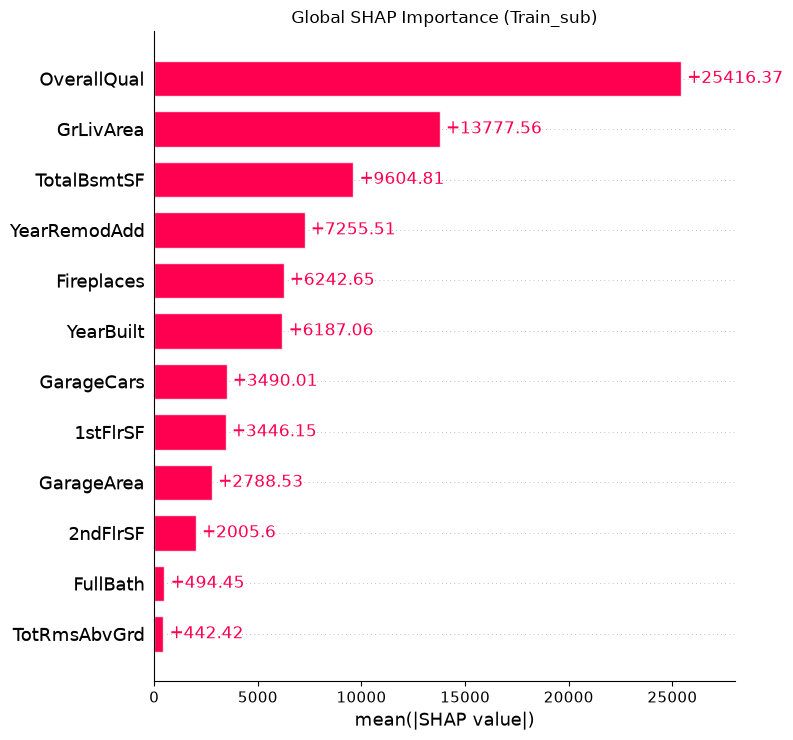


[Validation 첫 번째 주택]
실제 가격 : 140,000.0
예측 가격 : 149,904.4
오차      : 9,904.4


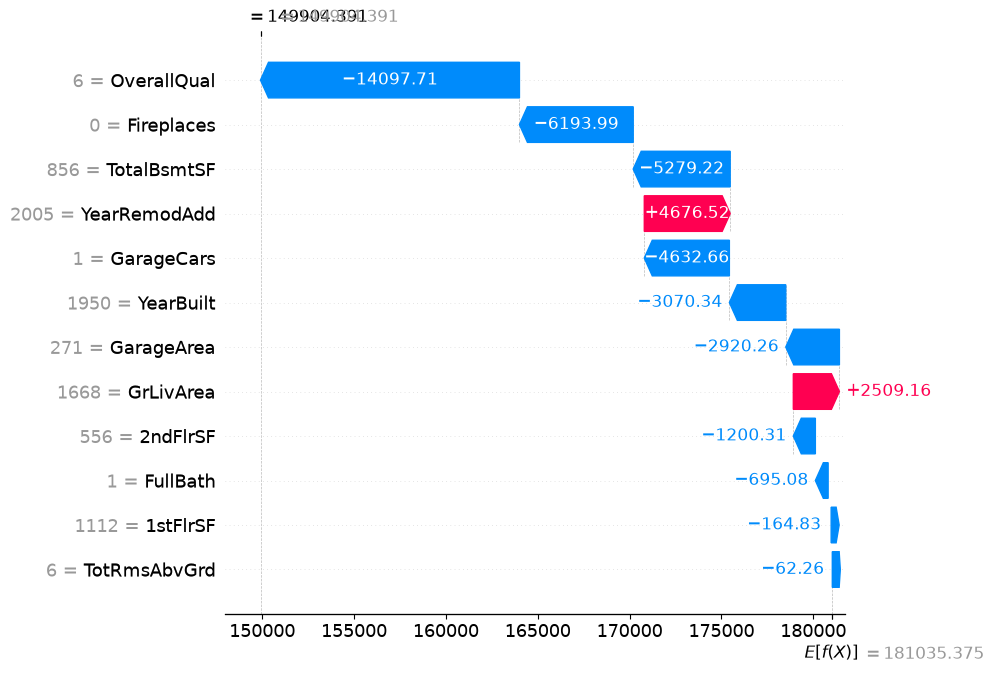


[local_top5]
     feature  feature_value  shap_value  abs_shap direction
 OverallQual              6    -14097.7   14097.7     하락(-)
  Fireplaces              0     -6194.0    6194.0     하락(-)
 TotalBsmtSF            856     -5279.2    5279.2     하락(-)
YearRemodAdd           2005      4676.5    4676.5     상승(+)
  GarageCars              1     -4632.7    4632.7     하락(-)

[SHAP 합 검증]
기준값(base_value)        : 181,035.4
SHAP 값 전체 합           : -31,131.0
기준값 + SHAP 합          : 149,904.4
모델 예측값               : 149,904.4
차이                      : 0.031250


In [8]:
# TODO 2: 과제용 XGBoost의 Feature Importance, Train_sub 전역 SHAP, Validation 첫 주택의 지역 SHAP을 확인하세요.

xgb_task = task_models["XGBoost"]

explainer = shap.TreeExplainer(xgb_task)
shap_sub = explainer(X_sub)

importance_comparison = pd.DataFrame({
    "feature": X_sub.columns,
    "feature_importance": xgb_task.feature_importances_.astype(float).round(4),
    "mean_abs_shap": np.abs(shap_sub.values).mean(axis=0).astype(float).round(1)
})
importance_comparison["fi_rank"] = (
    importance_comparison["feature_importance"].rank(ascending=False).astype(int))
importance_comparison["shap_rank"] = (
    importance_comparison["mean_abs_shap"].rank(ascending=False).astype(int))
importance_comparison["rank_diff"] = (
    importance_comparison["fi_rank"] - importance_comparison["shap_rank"])
importance_comparison = (importance_comparison
                         .sort_values("shap_rank").reset_index(drop=True))

print("[importance_comparison]")
print(importance_comparison.to_string(index=False))

shap.plots.bar(shap_sub, max_display=12, show=False)
plt.title("Global SHAP Importance (Train_sub)")
plt.tight_layout()
plt.show()

# --- Validation 첫 번째 주택 ---
shap_val = explainer(X_val)

actual = y_val.iloc[0]
predicted = xgb_task.predict(X_val.iloc[[0]])[0]

print(f"\n[Validation 첫 번째 주택]")
print(f"실제 가격 : {actual:,.1f}")
print(f"예측 가격 : {predicted:,.1f}")
print(f"오차      : {predicted - actual:,.1f}")

shap.plots.waterfall(shap_val[0], max_display=12)

local_top5 = pd.DataFrame({
    "feature": X_val.columns,
    "feature_value": X_val.iloc[0].values,
    "shap_value": shap_val.values[0].astype(float).round(1)
})
local_top5["abs_shap"] = local_top5["shap_value"].abs()
local_top5["direction"] = np.where(local_top5["shap_value"] > 0, "상승(+)", "하락(-)")
local_top5 = (local_top5.sort_values("abs_shap", ascending=False)
              .head(5).reset_index(drop=True))

print("\n[local_top5]")
print(local_top5.to_string(index=False))

base_value = float(shap_val.base_values[0])
shap_sum = float(shap_val.values[0].sum())
print(f"\n[SHAP 합 검증]")
print(f"기준값(base_value)        : {base_value:,.1f}")
print(f"SHAP 값 전체 합           : {shap_sum:,.1f}")
print(f"기준값 + SHAP 합          : {base_value + shap_sum:,.1f}")
print(f"모델 예측값               : {predicted:,.1f}")
print(f"차이                      : {abs(base_value + shap_sum - predicted):,.6f}")

In [9]:
# TODO 3: Train_sub SHAP 상위 6개 특성으로 재학습하고 동일 Validation에서 전후 성능을 비교하세요.

top6_features = importance_comparison.nsmallest(6, "shap_rank")["feature"].tolist()

print("선택한 상위 6개 특성 (Train_sub 평균 절댓값 SHAP 기준)")
print(importance_comparison.nsmallest(6, "shap_rank")[
    ["shap_rank", "feature", "mean_abs_shap"]].to_string(index=False))

X_sub_top6 = X_sub[top6_features]
X_val_top6 = X_val[top6_features]

xgb_top6 = XGBRegressor(
    n_estimators=200, learning_rate=0.05, max_depth=3,
    random_state=42, n_jobs=1
)
start = time.time()
xgb_top6.fit(X_sub_top6, y_sub)
top6_fit_time = time.time() - start

xgb_full = task_models["XGBoost"]
full_fit_time = model_comparison.loc[
    model_comparison["model"] == "XGBoost", "fit_time_sec"].values[0]

rows = []
for name, model, Xs, Xv, ft in [
    ("전체 특성", xgb_full, X_sub,      X_val,      full_fit_time),
    ("선택 특성", xgb_top6, X_sub_top6, X_val_top6, top6_fit_time),
]:
    val_pred = model.predict(Xv)
    rows.append({
        "model": name,
        "n_features": Xs.shape[1],
        "fit_time_sec": round(ft, 4),
        "train_sub_rmse": round(mean_squared_error(y_sub, model.predict(Xs)) ** 0.5, 1),
        "val_rmse": round(mean_squared_error(y_val, val_pred) ** 0.5, 1),
        "val_r2": round(r2_score(y_val, val_pred), 4),
    })

feature_comparison = pd.DataFrame(rows)
print("\n[feature_comparison]")
print(feature_comparison.to_string(index=False))

before, after = feature_comparison["val_rmse"]
diff = before - after
print(f"\n기존 Validation RMSE       : {before:,.1f}")
print(f"선택 후 Validation RMSE    : {after:,.1f}")
print(f"RMSE 차이 (기존 - 선택 후) : {diff:+,.1f}")
print(f"기존 대비 개선율           : {diff / before * 100:+.2f}%")
print(f"\n판정 : {'개선' if diff > 0 else '개선되지 않음'}")

선택한 상위 6개 특성 (Train_sub 평균 절댓값 SHAP 기준)
 shap_rank      feature  mean_abs_shap
         1  OverallQual        25416.4
         2    GrLivArea        13777.6
         3  TotalBsmtSF         9604.8
         4 YearRemodAdd         7255.5
         5   Fireplaces         6242.7
         6    YearBuilt         6187.1

[feature_comparison]
model  n_features  fit_time_sec  train_sub_rmse  val_rmse  val_r2
전체 특성          12        0.0317         19116.6   27436.8  0.8835
선택 특성           6        0.0212         20282.5   30029.9  0.8605

기존 Validation RMSE       : 27,436.8
선택 후 Validation RMSE    : 30,029.9
RMSE 차이 (기존 - 선택 후) : -2,593.1
기존 대비 개선율           : -9.45%

판정 : 개선되지 않음


## Q5~Q9 답변

### Q5. 전역 SHAP에서 가장 중요한 특성이 특정 주택에서도 반드시 가장 큰 영향을 주나요?  
- 두 값이 다른 것을 재기 때문에 **반드시 그렇지 않음**  

    - 전역 SHAP : 평균적으로 얼마나 크게 움직이는 특성인가    
-> Train_sub 934건의 기여도 절댓값을 평균한 값이므로 모델 전체의 평균적 경향을 나타내며,  
집집마다 값이 넓게 퍼져 있어 평균적으로 예측을 크게 움직이는 특성이 상위에 올라옴  

    - 지역 SHAP : 이 주택의 특성(Feature)값이 실제로 예측을 얼마나 움직였는가  
->  Validation 첫 번째 주택 1건의 SHAP 값을 평균하지 않고 그대로 본 값이므로 이 주택 1건의 특성값이 반영된 상태로 남아있음  
전역 순위가 낮은 특성이라도 그 주택에서 예측을 크게 움직였다면 기여도가 크게 나올 수 있음.  

전역 SHAP 1위 OverallQual(25,416.4)은 이 주택에서도 1위(절댓값 14,097.7)로 일치했으나,  
전역 SHAP 2위 GrLivArea(13,777.6)는 지역 SHAP 상위 5개에 포함되지 않았고, 전역 SHAP 7위 GarageCars(3,490.0)는 지역 SHAP 5위(절댓값 4,632.7)로 올라옴.

-> `따라서 전역 순위가 특정 주택에서 일치할 수도 있으나, 전역 1위가 그 주택에서도 반드시 큰 영향을 준다는 보장은 없음.`

### Q6. SHAP 값이 양수/음수라는 것은 각각 무엇을 의미하나요?  
- 기준값(base value)을 출발점으로 할 때 예측값을 어느 방향으로 움직였는지를 의미함  

    - 양수 : 예측값을 기준값보다 높이는 방향 
    - 음수 : 예측값을 기준값보다 낮추는 방향  

### Q7. 두 모델 중 무엇을 우선 후보로 선택했나요? 성능·학습 시간·과적합 징후와 주택 가격 예측 업무를 연결하여 설명하세요.  
- **XGBoost로 선택**  
    - `성능` : Validation RMSE가 RandomForest : 29,317.8 / XGBoost : 27,436.8로 XGBoost의 오차가 1,881 정도 더 적고,  
             Validation R²은 RandomForest : 0.8670 / XGBoost : 0.8835로 XGBoost가 0.0165정도 더 높은 설명력이 있다.  
             -> XGBoost가 RandomForest에 비해 RMSE도 더 낮고 R²도 더 높음  

    - `학습 시간` : XGBoost 0.0317초 / RandomForest 0.4057초로 XGBoost가 0.3740초 정도 더 짧게 측정되지만  
    -> 단, 한 번의 측정이고 두 모델의 max_depth 설정도 다르므로 알고리즘 자체의 속도 우열로 해석하지 않음

    - `과적합 징후` : RandomForest는 RMSE가 Train 12,367.7 / Validation 29,317.8로 차이가 16,950 정도이며,  
                   XGBoost는 RMSE가 Train 19,116.6 / Validation 27,436.8로 차이가 8,320 정도임.  
                   RandomForest의 오차 차이가 XGBoost보다 약 2배 크므로, RandomForest가 XGBoost보다 과적합 가능성이 높을 수 있음.  
-> 단, RandomForest는 max_depth를 지정하지 않고 학습, XGBoost는 max_depth=3으로 지정하여 학습했기 때문에 이 차이가 있을 수 있음  

    - `주택 가격 예측 업무와의 연결` : 처음 보는 매물의 가격을 예측해야 하므로 Train 적합도보다 보지 않은 데이터에서의 오차가 중요함  

-> RandomForest보다 성능이 더 높고 과적합 징후도 덜 나타나며, 시세 변동에 따라 주기적으로 재학습해야 하는 환경에서는 학습 시간이 짧게 측정된 `XGBoost`를 우선 후보로 선택

### Q8. Feature Importance와 평균 절댓값 SHAP의 계산 원리와 한계는 무엇이며, 실제 상위 특성 순위는 어떻게 다른가요?  

- Feature Importance : 모델 전체에서의 중요도 크기를 각 Feature 별로 보여줌
    - `원리` : 트리가 분할할 때마다 오차가 얼마나 줄었는지를 더해서, 전체 합이 1이 되게 나눈 값  
    (트리 분할 -> 분할 하나마다 '오차가 얼마나 줄었나'를 잼 -> 같은 특성이 쓰인 분할들을 모아 더함 -> 전체 합으로 나눠서 비율로 만듦)  
    - 학습된 트리 구조로 계산, 합이 1이 되는 상대 비중  
    -  `한계` : 방향 정보가 없어 값이 커질 때 예측을 올리는지 내리는지 알 수 없고, 상관이 높은 특성이 함께 있으면 중요도가 한쪽에 쏠릴 수 있음  

- 평균 절댓값 SHAP (전역 SHAP) : 그 특성 때문에 예측값이 실제로 얼마나 움직였는지를 Feature 별로 보여줌  
    - `원리` : 개별 샘플에서 각 특성이 예측값을 움직인 금액을 구하고, 부호를 없앤 뒤 전체 샘플에 대해 평균한 값  
    (샘플별 SHAP 값 계산 -> 절댓값을 씌워 부호 제거 -> 특성별로 전체 샘플에 대해 평균)  
    - 학습된 트리 구조와 데이터가 함께 필요하며, 단위가 예측 대상과 같은 달러임  
    - `한계` : 원본 SHAP 값에는 부호가 있으나 전역 SHAP는 절댓값을 평균하는 과정에서 방향이 사라지고,  
전체 샘플의 평균값이라 특정 주택의 기여도를 대표한다고 보기 어려움  

    - `실제 순위 차이` : 12개 중 10개의 순위가 바뀌었고, 그대로인 것은 OverallQual(1위)과 Fireplaces(5위) 2개.  
 3계단 이상 변동한 특성은 TotalBsmtSF(6→3), YearRemodAdd(9→4), GarageCars(2→7), 1stFlrSF(4→8)의 4개.  
 가장 큰 차이는 GarageCars로, Feature Importance 0.2052로 2위였으나 SHAP 3,490.0으로 7위로 내려감  
  반대로 YearRemodAdd는 Feature Importance 0.0254로 9위였으나 SHAP 7,255.5로 4위로 올라감  
-> 분할에 자주 사용된 특성이라도 그 분할이 예측값을 크게 움직이지 않았다면 SHAP 값은 작게 나오므로, 두 지표는 서로 다른 것을 잼  


### Q9. 상위 6개 특성은 무엇이며, 선택 전후 RMSE 차이와 개선율은 얼마인가요? 이 시도를 채택할지와 판단의 한계를 설명하세요.  
- **채택하지 않음**  

    - `상위 6개 특성` (Train_sub 평균 절댓값 SHAP 기준)  
-> OverallQual 25,416.4 / GrLivArea 13,777.6 / TotalBsmtSF 9,604.8 / YearRemodAdd 7,255.5 / Fireplaces 6,242.7 / YearBuilt 6,187.1  

    - `RMSE 차이와 개선율` : Validation RMSE 27,436.8 -> 30,029.9  
-> 기존-선택 후 = −2,593.1, 기존 대비 개선율 = −9.45%  

    - `채택하지 않는 이유` : Validation RMSE가 2,593.1 증가했으며, Train_sub RMSE도 19,116.6 -> 20,282.5로 1,165.9정도 올라감.  
과적합이 원인이라면 Validation만 올라가야하는데 양쪽이 모두 올라갔으므로, 제거한 특성이 담고 있던 정보가 예측에 기여하고 있었을 수 있음

    - `판단의 한계`  
-> 특성 개수는 비교 결과를 보기 전 6개로 고정했으며, 결과를 보고 개수를 바꾸지 않음  
-> Validation 234건 한 번의 결과이므로 분할이 달라지면 결과도 달라질 수 있음  
-> 최종 성능은 Test 데이터로 평가해야 확인할 수 있음  


---

# 실습 마무리

아래 질문에 짧게 답해보세요.

1. 배깅과 부스팅의 학습 방식 차이는 무엇인가요?  
-> 배깅 : 병렬, 독립 학습 후에 평균  
-> 부스팅 : 순차학습으로 이전 오차를 보완  

2. 배깅과 부스팅은 각각 편향과 분산 중 무엇을 줄이는 데 초점을 두나요?  
-> 배깅 : 주로 분산 감소  
-> 부스팅 : 주로 편향 감소  

3. 튜닝 여력이 부족한 상황에서는 어떤 모델군을 먼저 고려할 수 있나요?  
-> Random Forest를 베이스라인 후보로 고려할 수 있다.  

4. Feature Importance의 가장 큰 한계는 무엇인가요?  
-> 방향성, 개별 예측 근거를 알 기가 어려움  

5. SHAP의 전역 해석과 지역 해석은 무엇이 다른가요?  
-> 전역 : 모델 전처에서 중요한 특성 파악  
-> 지역 : 특정 샘플의 예측 근거 설명  

6. SHAP 값의 양수와 음수는 무엇을 의미하나요?  
-> 양수 : 예측값 상승 방향  
-> 음수 : 예측값 하락 방향